<a href="https://colab.research.google.com/github/kjfcvx12/Colab/blob/main/05-04-02-AutoEncoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from torchvision import datasets, transforms

In [2]:
# 전처리
transform=transforms.Compose([
    transforms.ToTensor()
])

In [3]:
train_dataset=datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)

100%|██████████| 26.4M/26.4M [00:00<00:00, 115MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.98MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 60.2MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.1MB/s]


In [4]:
test_dataset=datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

In [5]:
train_dataset.data.shape, test_dataset.data.shape

(torch.Size([60000, 28, 28]), torch.Size([10000, 28, 28]))

In [6]:
# cnn(Batch_size, C, H, W)

In [7]:
class ConvolutionalAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            # conv_1: (1, 28, 28) -> (64, 28, 28)
            # padding=1 : 필터 연산 후에도 입력, 출력 이미지 가로/세로 크기 똑같이 유지되게
            nn.Conv2d(in_channels=1, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            # maxpool_1: (64, 28, 28) -> (64, 14, 14)
            nn.MaxPool2d(kernel_size=2, stride=2),

            # conv_2: (64, 14, 14) -> (128, 14, 14)
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            # maxpool_2: (128, 14, 14) -> (128, 7, 7)
            nn.MaxPool2d(kernel_size=2, stride=2),

            # bottle_neck: (128, 7, 7) -> (256, 7, 7)
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            # conv_3: (256, 7, 7) -> (128, 7, 7)
            nn.Conv2d(in_channels=256, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            # upsample_3: (128, 7, 7) -> (128, 14, 14)
            # 이미지 2배로 키움
            nn.Upsample(scale_factor=2, mode='nearest'),

            # conv_4: (128, 14, 14) -> (64, 14, 14)
            nn.Conv2d(in_channels=128, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            # upsample_4: (64, 14, 14) -> (64, 28, 28)
            nn.Upsample(scale_factor=2, mode='nearest'),

            # conv_5: (64, 28, 28) -> (1, 28, 28)
            nn.Conv2d(in_channels=64, out_channels=1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [8]:
# 디코더 : 256개 채널 가진 데이터 입력받아서 3*3 크기의 필터 128개를 사용해 이미지를 훑는다
# 패딩 1을 적용해 가로/세로 크기는 유지하면서 128개의 채널로 압축한다.
model=ConvolutionalAutoencoder()
model

ConvolutionalAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
  )
  (decoder): Sequential(
    (0): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Upsample(scale_factor=2.0, mode='nearest')
    (3): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): Upsample(scale_factor=2.0, mode='nearest')
    (6): Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): Sigmoid()
  )
)

In [9]:
bceloss=nn.BCELoss()
optimizer=optim.Adam(model.parameters(), lr=0.001)

In [10]:
!pip install torchview graphviz

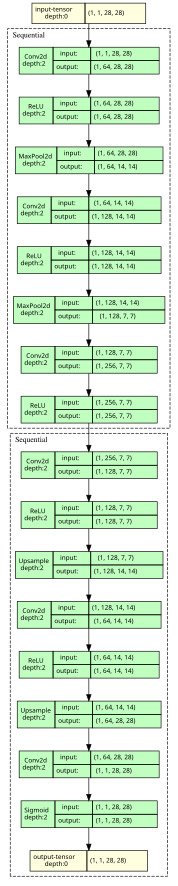

In [11]:
# !pip install torchview graphviz

from torchview import draw_graph
import graphviz


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


model_graph = draw_graph(
    model,
    input_size=(1, 1, 28, 28), # (Batch, Channel, Height, Width)
    expand_nested=True,
    graph_name="Autoencoder",
    device=device
)


model_graph.visual_graph
# 만약 파일로 저장하고 싶다면:
# model_graph.visual_graph.render("autoencoder_structure", format="png")

In [14]:

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)


history = {'loss': [], 'val_loss': []}

# 학습 루프
epochs = 20

for epoch in range(epochs):
    model.train() # 모델을 학습 모드로 설정
    train_loss = 0.0

    for data, _ in train_loader:
        # 데이터를 장치(GPU/CPU)로 이동
        inputs = data.to(device)

        # Gradient 초기화
        optimizer.zero_grad()

        # Forward: 모델에 입력 (X_train을 넣고 X_train이 나오게 함)
        outputs = model(inputs)

        # Loss 계산 (Reconstruction Error)
        loss = bceloss(outputs, inputs)

        # Backward: 역전파 (기울기 계산)
        loss.backward()

        # Optimizer Step: 가중치 업데이트
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)


    model.eval() # 모델을 평가 모드로 설정
    val_loss = 0.0
    with torch.no_grad():
        for data, _ in test_loader:
            inputs = data.to(device)
            outputs = model(inputs)
            loss = bceloss(outputs, inputs)
            val_loss += loss.item() * inputs.size(0)

    # 에포크별 평균 손실 계산 및 기록
    avg_train_loss = train_loss / len(train_loader.dataset)
    avg_val_loss = val_loss / len(test_loader.dataset)

    history['loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)

    print(f'Epoch [{epoch+1}/{epochs}] - Loss: {avg_train_loss:.4f}, Val_Loss: {avg_val_loss:.4f}')

Epoch [1/20] - Loss: 0.2541, Val_Loss: 0.2552
Epoch [2/20] - Loss: 0.2531, Val_Loss: 0.2543
Epoch [3/20] - Loss: 0.2520, Val_Loss: 0.2537
Epoch [4/20] - Loss: 0.2513, Val_Loss: 0.2531
Epoch [5/20] - Loss: 0.2506, Val_Loss: 0.2524
Epoch [6/20] - Loss: 0.2501, Val_Loss: 0.2522
Epoch [7/20] - Loss: 0.2498, Val_Loss: 0.2514
Epoch [8/20] - Loss: 0.2493, Val_Loss: 0.2511
Epoch [9/20] - Loss: 0.2491, Val_Loss: 0.2508
Epoch [10/20] - Loss: 0.2487, Val_Loss: 0.2506
Epoch [11/20] - Loss: 0.2486, Val_Loss: 0.2507
Epoch [12/20] - Loss: 0.2482, Val_Loss: 0.2501
Epoch [13/20] - Loss: 0.2481, Val_Loss: 0.2500
Epoch [14/20] - Loss: 0.2479, Val_Loss: 0.2500
Epoch [15/20] - Loss: 0.2477, Val_Loss: 0.2496
Epoch [16/20] - Loss: 0.2476, Val_Loss: 0.2495
Epoch [17/20] - Loss: 0.2474, Val_Loss: 0.2493
Epoch [18/20] - Loss: 0.2473, Val_Loss: 0.2493
Epoch [19/20] - Loss: 0.2472, Val_Loss: 0.2492
Epoch [20/20] - Loss: 0.2470, Val_Loss: 0.2489


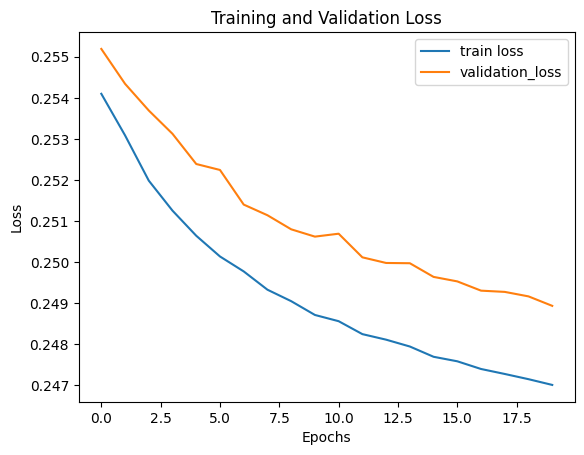

In [15]:
plt.plot(history['loss'], label='train loss')
plt.plot(history['val_loss'], label='validation_loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

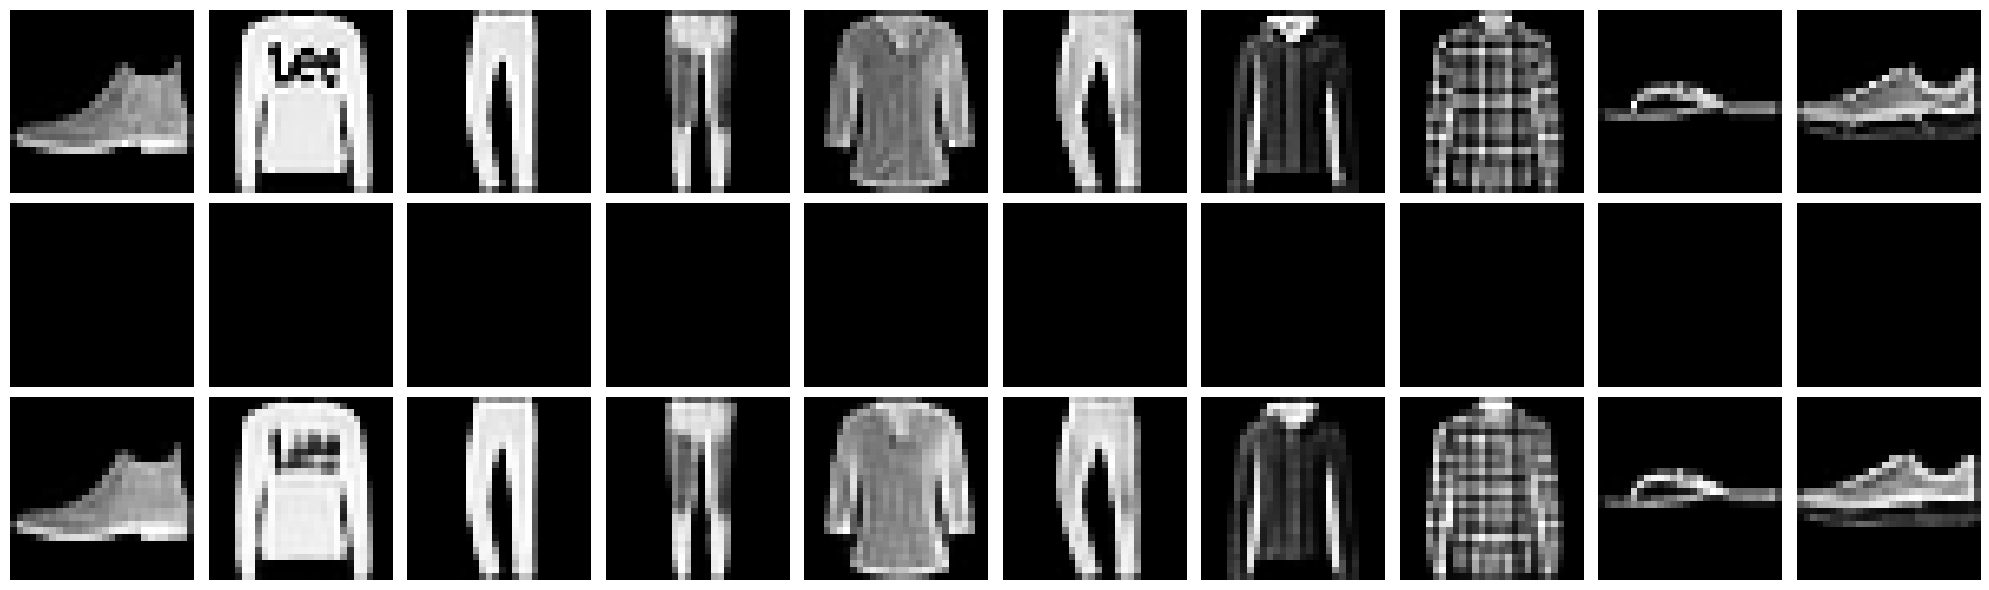

In [17]:
# 모델을 평가 모드로 설정
model.eval()

fig, ax = plt.subplots(3, 10, figsize=(20, 6))

with torch.no_grad():
    for i in range(10):
        # 1. 데이터 준비 (Test Dataset에서 i번째 이미지 가져오기)
        img_tensor, _ = test_dataset[i]
        # 모델에 이미지 넣으려고 가상 배치 하나 추가함(4차원으로 만듬)
        img_input = img_tensor.unsqueeze(0).to(device) # (1, 1, 28, 28)

        # 2. 모델 예측 (인코더 출력 및 전체 복원 출력)
        encoded_features = model.encoder(img_input) # (1, 256, 7, 7)
        decoded_img = model(img_input)              # (1, 1, 28, 28)

        # 3. 시각화를 위한 넘파이 변환 및 차원 정리
        original = img_tensor.squeeze().cpu().numpy()
        # [0]을 사용하여 256개 채널 중 첫 번째 특징 맵만 추출 (7, 7)
        encoded = encoded_features.squeeze().cpu().numpy()[0]
        decoded = decoded_img.squeeze().cpu().numpy()

        # --- 이미지 출력 ---
        # 원본 (28x28)
        ax[0, i].imshow(original, cmap='gray')
        ax[0, i].axis('off')

        # 잠재 공간 특징 (7x7) - 에러 해결 포인트
        ax[1, i].imshow(encoded, cmap='gray')
        ax[1, i].axis('off')

        # 복원 이미지 (28x28)
        ax[2, i].imshow(decoded, cmap='gray')
        ax[2, i].axis('off')

plt.tight_layout()
plt.show()